# 24ADI306 Deep Learning: Self-Learning Assignment 1
## Exploring Word Representations: From Traditional Word Embeddings to Transformers

**NAME : ROSHNI ANGEL A / ROLL NO : 24BAD101**

**PROCESS OF THE WORK**
1. Builds *traditional* representations (One-Hot, BoW, TF-IDF, N-grams, Co-occurrence + SVD/LSA)
2. Trains *neural* embeddings with the TensorFlow/Keras `Embedding` layer (a from-scratch Skip-gram with negative sampling)
3. Trains *Word2Vec* (Skip-gram and CBOW) and *FastText*, and loads pretrained *GloVe*
4. Extracts *contextual* embeddings from *BERT* (and sentence embeddings from SBERT)
5. Finds the top-5 similar words with cosine similarity, visualizes embeddings (PCA, t-SNE, UMAP, TF Embedding Projector) and compares everything



In [1]:
!pip -q install gensim transformers sentence-transformers umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 25.4 MB/s eta 0:00:00


In [2]:
import os, re, random, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import gensim, tensorflow as tf
from collections import Counter
from gensim.utils import simple_preprocess
from gensim.models import Word2Vec, FastText
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

SEED = 1
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
USE_20NG = False          # True -> larger 20 Newsgroups subset
print("gensim", gensim.__version__, "| TF", tf.__version__)

gensim 4.4.0 | TF 2.20.0


## 0. Dataset and preprocessing

In [3]:
if USE_20NG:
    from sklearn.datasets import fetch_20newsgroups
    cats = ["sci.space", "rec.autos", "talk.politics.mideast", "comp.graphics", "rec.sport.hockey"]
    docs = fetch_20newsgroups(subset="train", categories=cats,
                              remove=("headers", "footers", "quotes")).data
    docs = [d.strip() for d in docs if len(d.split()) > 20]
else:
    path = os.path.join(os.path.dirname(gensim.__file__), "test", "test_data", "lee_background.cor")
    docs = [l.strip() for l in open(path, encoding="utf-8") if l.strip()]

tok = [simple_preprocess(d, min_len=2) for d in docs]      # lowercase + tokenize
print("documents:", len(docs), "| tokens:", sum(map(len, tok)), "| unique:", len({w for s in tok for w in s}))
print("\nSample:", docs[0][:200], "...")

documents: 300 | tokens: 58152 | unique: 6981

Sample: Hundreds of people have been forced to vacate their homes in the Southern Highlands of New South Wales as strong winds today pushed a huge bushfire towards the town of Hill Top. A new blaze near Goulb ...


## 1. Traditional text representations
These are *sparse, count-based* vectors. They ignore word order (except N-grams) and cannot express meaning.

In [4]:
# --- One-Hot Encoding on a tiny example ---
sent = "the king rules the kingdom".split()
vocab_small = sorted(set(sent))
onehot = pd.DataFrame(np.eye(len(vocab_small), dtype=int), index=vocab_small, columns=vocab_small)
print(onehot)
print("\ncosine(king, kingdom) =", cosine_similarity(onehot.loc[["king"]], onehot.loc[["kingdom"]])[0, 0],
      "-> every pair of different words is orthogonal (no similarity information)")

         king  kingdom  rules  the
king        1        0      0    0
kingdom     0        1      0    0
rules       0        0      1    0
the         0        0      0    1

cosine(king, kingdom) = 0.0 -> every pair of different words is orthogonal (no similarity information)


In [5]:
# --- Bag of Words, TF-IDF and N-grams on the corpus ---
bow = CountVectorizer(stop_words="english", min_df=3)
X_bow = bow.fit_transform(docs)
tfidf = TfidfVectorizer(stop_words="english", min_df=3)
X_tfidf = tfidf.fit_transform(docs)
bigram = CountVectorizer(ngram_range=(1, 2), stop_words="english", min_df=3).fit(docs)

print("BoW matrix    :", X_bow.shape, f"| sparsity = {1 - X_bow.nnz / np.prod(X_bow.shape):.3%}")
print("TF-IDF matrix :", X_tfidf.shape)
print("Vocabulary with 1+2-grams:", len(bigram.vocabulary_), "(vs", len(bow.vocabulary_), "unigrams)")

# Words with the highest average TF-IDF weight
terms = tfidf.get_feature_names_out()
top = np.asarray(X_tfidf.mean(axis=0)).ravel().argsort()[::-1][:10]
print("Top TF-IDF terms:", [terms[i] for i in top])

BoW matrix    : (300, 2212) | sparsity = 97.154%
TF-IDF matrix : (300, 2212)
Vocabulary with 1+2-grams: 2883 (vs 2212 unigrams)
Top TF-IDF terms: ['says', 'said', 'mr', 'palestinian', 'australia', 'new', 'australian', 'government', 'south', 'people']


### 1b. Frequency/matrix-based embeddings: Co-occurrence, SVD and LSA
A TF-IDF *term-document* matrix has one row per word, but each row is as long as the number of documents. Truncated **SVD** compresses it into dense 100-d vectors, which is **Latent Semantic Analysis (LSA)**.

In [6]:
svd = TruncatedSVD(n_components=100, random_state=SEED)
lsa_vecs = svd.fit_transform(X_tfidf.T)          # rows = words, 100 dense dims
print("LSA word vectors:", lsa_vecs.shape, "| variance explained:", round(svd.explained_variance_ratio_.sum(), 3))

# Word-word co-occurrence matrix (window = 4) built by hand
def cooccurrence(tokens_list, vocab, window=4):
    idx = {w: i for i, w in enumerate(vocab)}
    M = np.zeros((len(vocab), len(vocab)), dtype=np.float32)
    for s in tokens_list:
        ids = [idx[w] for w in s if w in idx]
        for i, a in enumerate(ids):
            for b in ids[max(0, i - window): i]:
                M[a, b] += 1; M[b, a] += 1
    return M
top_vocab = [w for w, _ in Counter(w for s in tok for w in s).most_common(500)]
M = cooccurrence(tok, top_vocab)
print("Co-occurrence matrix (500 most frequent words):", M.shape)

LSA word vectors: (2212, 100) | variance explained: 0.618
Co-occurrence matrix (500 most frequent words): (500, 500)


### Helper: top-5 most similar words by cosine similarity (Experimental Task 2)

In [7]:
def topk_matrix(word, vecs, words, k=5):
    """vecs: (n_words, dim) array (dense or sparse); words: list aligned with rows."""
    idx = {w: i for i, w in enumerate(words)}
    if word not in idx: return "not in vocabulary"
    sims = cosine_similarity(vecs[idx[word]].reshape(1, -1) if not hasattr(vecs, "tocsr") else vecs[idx[word]], vecs).ravel()
    sims[idx[word]] = -1
    return [(words[i], round(float(sims[i]), 3)) for i in sims.argsort()[::-1][:k]]

terms = list(tfidf.get_feature_names_out())
tfidf_word_vecs = X_tfidf.T.tocsr()               # each word = its column of the TF-IDF matrix
queries = ["government", "police", "israeli", "minister", "fire"]
for q in queries:
    print(f"{q:10s} TF-IDF:", topk_matrix(q, tfidf_word_vecs, terms))
    print(f"{'':10s} LSA   :", topk_matrix(q, lsa_vecs, terms))

government TF-IDF: [('unity', 0.413), ('minister', 0.404), ('says', 0.399), ('riots', 0.392), ('federal', 0.382)]
           LSA   : [('unity', 0.516), ('riots', 0.511), ('does', 0.506), ('budget', 0.506), ('minister', 0.499)]
police     TF-IDF: [('vehicle', 0.437), ('shopping', 0.389), ('kilometres', 0.372), ('inside', 0.367), ('arrested', 0.366)]
           LSA   : [('160', 0.561), ('shopping', 0.557), ('vehicle', 0.548), ('inside', 0.548), ('dozens', 0.537)]
israeli    TF-IDF: [('palestinian', 0.84), ('ariel', 0.681), ('arafat', 0.651), ('palestinians', 0.611), ('sharon', 0.589)]
           LSA   : [('palestinian', 0.913), ('ariel', 0.891), ('palestinians', 0.884), ('islamic', 0.812), ('ramallah', 0.804)]
minister   TF-IDF: [('prime', 0.656), ('foreign', 0.559), ('alexander', 0.424), ('government', 0.404), ('says', 0.372)]
           LSA   : [('prime', 0.71), ('foreign', 0.676), ('alexander', 0.518), ('government', 0.499), ('does', 0.488)]
fire       TF-IDF: not in vocabulary
      

## 2. Neural embeddings with TensorFlow / Keras
### 2a. The `Embedding` layer
`layers.Embedding(vocab_size, dim)` is a trainable lookup table of shape `(vocab_size, dim)`. Passing integer word ids returns the corresponding rows. It is mathematically identical to multiplying a one-hot vector by a weight matrix, just far cheaper.

In [8]:
from tensorflow.keras import layers
demo = layers.Embedding(input_dim=10, output_dim=4)
ids = tf.constant([[1, 2, 3], [4, 5, 6]])            # batch of 2 sequences, 3 tokens each
print("Input shape :", ids.shape)
print("Output shape:", demo(ids).shape, "-> (batch, sequence, embedding_dim)")
print("Weight matrix shape:", demo.get_weights()[0].shape)

Input shape : (2, 3)
Output shape: (2, 3, 4) -> (batch, sequence, embedding_dim)
Weight matrix shape: (10, 4)


### 2b. Skip-gram with negative sampling (SGNS) in Keras
The model learns two tables, a *target* embedding and a *context* embedding. For each (target, context) pair it predicts the label 1 if the pair really co-occurred and 0 for randomly sampled negatives. After training, the target table holds the word vectors.

In [9]:
counts = Counter(w for s in tok for w in s)
itos = ["<pad>"] + [w for w, c in counts.most_common() if c >= 5]
stoi = {w: i for i, w in enumerate(itos)}
V = len(itos)
seqs = [[stoi[w] for w in s if w in stoi] for s in tok]

pairs, labels = [], []
for s in seqs:
    p, l = tf.keras.preprocessing.sequence.skipgrams(s, V, window_size=4, negative_samples=4, seed=SEED)
    pairs += p; labels += l
pairs = np.array(pairs); labels = np.array(labels, dtype="float32")
print("Vocabulary:", V, "| training pairs:", len(pairs), f"| positives: {labels.mean():.1%}")

DIM = 50
t_in = layers.Input((1,)); c_in = layers.Input((1,))
target_emb = layers.Embedding(V, DIM, name="target_emb")
context_emb = layers.Embedding(V, DIM, name="context_emb")
dots = layers.Dot(axes=2)([target_emb(t_in), context_emb(c_in)])
out = layers.Activation("sigmoid")(layers.Flatten()(dots))
sgns = tf.keras.Model([t_in, c_in], out)
sgns.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
hist = sgns.fit([pairs[:, 0], pairs[:, 1]], labels, batch_size=1024, epochs=5, verbose=2)

Vocabulary: 1751 | training pairs: 1943400 | positives: 20.0%
Epoch 1/5
1898/1898 - 9s - 5ms/step - accuracy: 0.8551 - loss: 0.3918
Epoch 2/5
1898/1898 - 10s - 5ms/step - accuracy: 0.8723 - loss: 0.3370
Epoch 3/5
1898/1898 - 10s - 5ms/step - accuracy: 0.8739 - loss: 0.3312
Epoch 4/5
1898/1898 - 17s - 9ms/step - accuracy: 0.8757 - loss: 0.3244
Epoch 5/5
1898/1898 - 12s - 6ms/step - accuracy: 0.8775 - loss: 0.3173


minister   Keras SGNS: [('alexander', 0.935), ('foreign', 0.912), ('downer', 0.904), ('prime', 0.899), ('affairs', 0.885)]
israeli    Keras SGNS: [('blasted', 0.928), ('launched', 0.917), ('offices', 0.917), ('bus', 0.914), ('earlier', 0.913)]
police     Keras SGNS: [('sent', 0.9), ('sunday', 0.892), ('fired', 0.888), ('tanks', 0.888), ('follows', 0.886)]


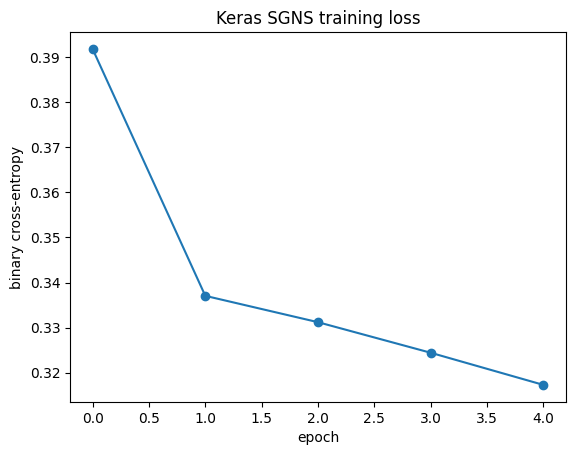

In [10]:
W = target_emb.get_weights()[0]
keras_vecs = W / np.linalg.norm(W, axis=1, keepdims=True)
for q in ["minister", "israeli", "police"]:
    print(f"{q:10s} Keras SGNS:", topk_matrix(q, keras_vecs, itos))
plt.plot(hist.history["loss"], marker="o"); plt.title("Keras SGNS training loss")
plt.xlabel("epoch"); plt.ylabel("binary cross-entropy"); plt.show()

## 3. Word2Vec (Skip-gram and CBOW), FastText and GloVe
* **CBOW** predicts the centre word from the average of its context words (faster, good for frequent words).
* **Skip-gram** predicts each context word from the centre word (slower, better for rare words).

In [11]:
common = dict(vector_size=100, window=5, min_count=5, epochs=100, seed=SEED, workers=1)
w2v_sg = Word2Vec(tok, sg=1, **common)
w2v_cbow = Word2Vec(tok, sg=0, **common)
print("Vocabulary size:", len(w2v_sg.wv))
for q in queries:
    print(f"{q:10s} Skip-gram:", [(w, round(s, 3)) for w, s in w2v_sg.wv.most_similar(q, topn=5)])
    print(f"{'':10s} CBOW     :", [(w, round(s, 3)) for w, s in w2v_cbow.wv.most_similar(q, topn=5)])

Vocabulary size: 1750
government Skip-gram: [('interim', 0.498), ('federal', 0.425), ('affairs', 0.425), ('pacific', 0.405), ('alexander', 0.404)]
           CBOW     : [('administration', 0.412), ('work', 0.389), ('projects', 0.388), ('opposition', 0.358), ('solomon', 0.344)]
police     Skip-gram: [('afroz', 0.453), ('vehicle', 0.436), ('headquarters', 0.434), ('officers', 0.429), ('inside', 0.429)]
           CBOW     : [('witnesses', 0.468), ('afroz', 0.418), ('officers', 0.417), ('mohammed', 0.401), ('confirm', 0.364)]
israeli    Skip-gram: [('palestinian', 0.656), ('israel', 0.582), ('tanks', 0.523), ('targets', 0.513), ('sharon', 0.507)]
           CBOW     : [('targets', 0.478), ('israelis', 0.466), ('tanks', 0.463), ('israel', 0.462), ('helicopters', 0.454)]
minister   Skip-gram: [('prime', 0.784), ('alexander', 0.636), ('foreign', 0.633), ('philip', 0.616), ('ariel', 0.605)]
           CBOW     : [('affairs', 0.579), ('philip', 0.501), ('alexander', 0.485), ('ministry', 0.465)

In [12]:
# Vector arithmetic / analogy test (works only if the corpus is large enough)
try:
    print(w2v_sg.wv.most_similar(positive=["minister", "israeli"], negative=["government"], topn=3))
except KeyError as e:
    print("Word missing from vocabulary:", e)
print("cosine(minister, prime)   =", round(w2v_sg.wv.similarity("minister", "prime"), 3))
print("cosine(minister, police)  =", round(w2v_sg.wv.similarity("minister", "police"), 3))

[('ariel', 0.5026425123214722), ('prime', 0.4543946087360382), ('foreign', 0.43955251574516296)]
cosine(minister, prime)   = 0.784
cosine(minister, police)  = 0.191


In [13]:
# --- FastText: subword n-grams handle rare / out-of-vocabulary (OOV) words ---
ft = FastText(tok, sg=1, min_n=3, max_n=6, **common)
for w in ["governments", "policemen", "ministerial"]:
    in_w2v, in_ft = w in w2v_sg.wv.key_to_index, w in ft.wv.key_to_index
    print(f"\n'{w}'  in training vocab? Word2Vec={in_w2v}, FastText={in_ft}")
    try: w2v_sg.wv[w]
    except KeyError: print("  Word2Vec  -> KeyError (no vector)")
    print("  FastText  ->", [(a, round(b, 3)) for a, b in ft.wv.most_similar(w, topn=3)])


'governments'  in training vocab? Word2Vec=False, FastText=False
  Word2Vec  -> KeyError (no vector)
  FastText  -> [('government', 0.865), ('documents', 0.505), ('interim', 0.503)]

'policemen'  in training vocab? Word2Vec=False, FastText=False
  Word2Vec  -> KeyError (no vector)
  FastText  -> [('police', 0.841), ('offices', 0.53), ('radical', 0.518)]

'ministerial'  in training vocab? Word2Vec=False, FastText=False
  Word2Vec  -> KeyError (no vector)
  FastText  -> [('minister', 0.892), ('ministers', 0.796), ('prime', 0.697)]


In [14]:
# --- GloVe (pretrained on Wikipedia + Gigaword, 100-d) ---
import gensim.downloader as api
glove = api.load("glove-wiki-gigaword-100")
print("GloVe vocab:", len(glove.key_to_index))
for q in queries:
    print(f"{q:10s} GloVe:", [(w, round(s, 3)) for w, s in glove.most_similar(q, topn=5)])
print(glove.most_similar(positive=["king", "woman"], negative=["man"], topn=3))

[==================================================] 100.0% 128.1/128.1MB downloaded
GloVe vocab: 400000
government GloVe: [('administration', 0.794), ('governments', 0.77), ('officials', 0.759), ('authorities', 0.744), ('opposition', 0.737)]
police     GloVe: [('officers', 0.832), ('policemen', 0.811), ('authorities', 0.798), ('arrested', 0.76), ('guards', 0.736)]
israeli    GloVe: [('palestinian', 0.884), ('israel', 0.855), ('palestinians', 0.802), ('israelis', 0.792), ('lebanese', 0.778)]
minister   GloVe: [('prime', 0.882), ('cabinet', 0.745), ('ministry', 0.745), ('foreign', 0.729), ('deputy', 0.728)]
fire       GloVe: [('fires', 0.752), ('fired', 0.741), ('firing', 0.73), ('attack', 0.719), ('explosion', 0.7)]
[('queen', 0.7698540687561035), ('monarch', 0.6843381524085999), ('throne', 0.6755736470222473)]


## 4. Contextual embeddings with BERT and Sentence-BERT
Static embeddings assign **one vector per word type**. BERT computes a **different vector for every occurrence** using self-attention over the whole sentence.

In [15]:
import torch
from transformers import AutoTokenizer, AutoModel
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
bert = AutoModel.from_pretrained("bert-base-uncased").eval()

def word_vector(sentence, word):
    enc = tokenizer(sentence, return_tensors="pt")
    with torch.no_grad():
        hidden = bert(**enc).last_hidden_state[0]           # (tokens, 768)
    pieces = tokenizer.convert_ids_to_tokens(enc["input_ids"][0])
    return hidden[pieces.index(word)].numpy()

sents = {
    "river_1": "He sat on the bank of the river and watched the water.",
    "money_1": "She deposited her salary at the bank on Monday.",
    "money_2": "The bank approved the loan after checking her income.",
    "river_2": "Fishermen gathered along the muddy bank of the stream.",
}
B = {k: word_vector(s, "bank") for k, s in sents.items()}
keys = list(B)
sim = pd.DataFrame(cosine_similarity(np.array([B[k] for k in keys])), index=keys, columns=keys).round(3)
print("BERT cosine similarity between the vectors of 'bank' in different sentences:")
print(sim)
print("\nStatic Word2Vec/GloVe: cosine(bank_river, bank_money) is always exactly 1.0 (one vector per word).")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT cosine similarity between the vectors of 'bank' in different sentences:
         river_1  money_1  money_2  river_2
river_1    1.000    0.491    0.415    0.842
money_1    0.491    1.000    0.850    0.456
money_2    0.415    0.850    1.000    0.390
river_2    0.842    0.456    0.390    1.000

Static Word2Vec/GloVe: cosine(bank_river, bank_money) is always exactly 1.0 (one vector per word).


In [16]:
from sentence_transformers import SentenceTransformer
sbert = SentenceTransformer("all-MiniLM-L6-v2")
s = ["The stock market fell sharply today.",
     "Shares dropped heavily on the exchange.",
     "The chef cooked a delicious pasta dinner."]
E = sbert.encode(s)
print(pd.DataFrame(cosine_similarity(E), index=["market", "shares", "chef"], columns=["market", "shares", "chef"]).round(3))

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

        market  shares   chef
market   1.000   0.567 -0.004
shares   0.567   1.000 -0.079
chef    -0.004  -0.079  1.000


## 5. Similar-word comparison table (top-5 neighbours per method)

In [17]:
def w2v_top(m, q): return ", ".join(w for w, _ in m.wv.most_similar(q, topn=5)) if q in m.wv else "-"
def mat_top(q, v, words):
    r = topk_matrix(q, v, words); return ", ".join(w for w, _ in r) if isinstance(r, list) else "-"
rows = []
for q in ["government", "police", "israeli", "minister"]:
    rows.append({"query": q,
                 "TF-IDF": mat_top(q, tfidf_word_vecs, terms),
                 "LSA": mat_top(q, lsa_vecs, terms),
                 "Word2Vec Skip-gram": w2v_top(w2v_sg, q),
                 "Word2Vec CBOW": w2v_top(w2v_cbow, q),
                 "FastText": w2v_top(ft, q)})
pd.set_option("display.max_colwidth", 60)
pd.DataFrame(rows).set_index("query")

,TF-IDF,LSA,Word2Vec Skip-gram,Word2Vec CBOW,FastText
query,,,,,
government,"unity, minister, says, riots, federal","unity, riots, does, budget, minister","interim, federal, affairs, pacific, alexander","administration, work, projects, opposition, solomon","cut, interim, solution, hamid, policy"
police,"vehicle, shopping, kilometres, inside, arrested","160, shopping, vehicle, inside, dozens","afroz, vehicle, headquarters, officers, inside","witnesses, afroz, officers, mohammed, confirm","afroz, arrested, destroyed, vehicle, officers"
israeli,"palestinian, ariel, arafat, palestinians, sharon","palestinian, ariel, palestinians, islamic, ramallah","palestinian, israel, tanks, targets, sharon","targets, israelis, tanks, israel, helicopters","israelis, israel, palestinian, palestinians, strip"
minister,"prime, foreign, alexander, government, says","prime, foreign, alexander, government, does","prime, alexander, foreign, philip, ariel","affairs, philip, alexander, ministry, prime","prime, ministers, foreign, alexander, philip"


## 6. Embedding visualization (PCA, t-SNE, UMAP, TensorFlow Embedding Projector)

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


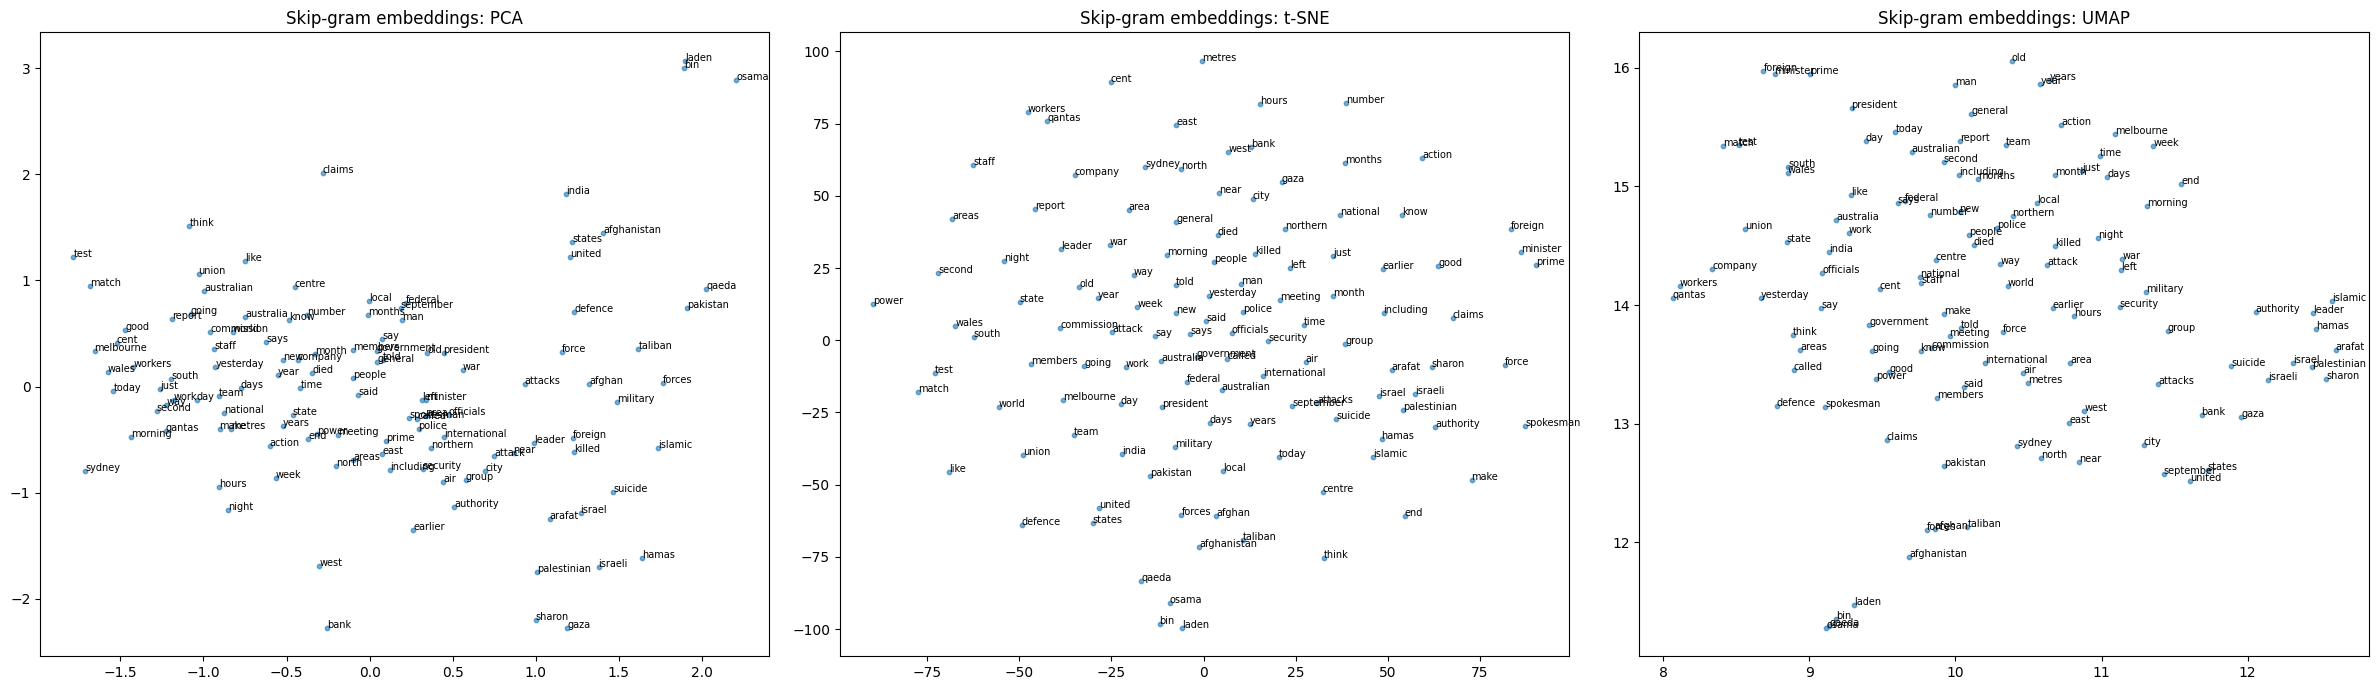

In [18]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
content = [w for w in w2v_sg.wv.key_to_index if w not in ENGLISH_STOP_WORDS and len(w) > 2]
freq_words = sorted(content, key=lambda w: w2v_sg.wv.get_vecattr(w, "count"), reverse=True)[:120]   # frequent content words
Vec = np.array([w2v_sg.wv[w] for w in freq_words])
pca_xy = PCA(2, random_state=SEED).fit_transform(Vec)
tsne_xy = TSNE(2, perplexity=20, init="pca", random_state=SEED).fit_transform(Vec)
try:
    import umap
    umap_xy = umap.UMAP(n_neighbors=10, random_state=SEED).fit_transform(Vec)
except ImportError:
    umap_xy = None

plots = [("PCA", pca_xy), ("t-SNE", tsne_xy)] + ([("UMAP", umap_xy)] if umap_xy is not None else [])
fig, axes = plt.subplots(1, len(plots), figsize=(8 * len(plots), 7))
for ax, (name, xy) in zip(np.atleast_1d(axes), plots):
    ax.scatter(xy[:, 0], xy[:, 1], s=10, alpha=.6)
    for i, w in enumerate(freq_words): ax.annotate(w, xy[i], fontsize=7)
    ax.set_title(f"Skip-gram embeddings: {name}")
plt.tight_layout(); plt.savefig("embeddings_2d.png", dpi=150); plt.show()

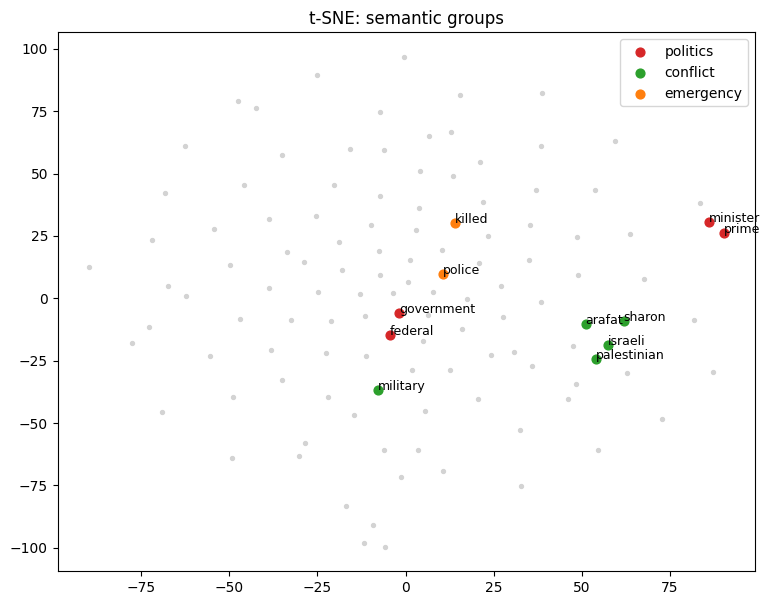

In [19]:
# Highlight a few semantic groups on the t-SNE map
groups = {"politics": ["government", "minister", "prime", "federal", "opposition", "party"],
          "conflict": ["israeli", "palestinian", "arafat", "sharon", "military", "tanks"],
          "emergency": ["police", "fire", "crews", "officers", "arrested", "killed"]}
colors = {"politics": "tab:red", "conflict": "tab:green", "emergency": "tab:orange"}
plt.figure(figsize=(9, 7))
plt.scatter(tsne_xy[:, 0], tsne_xy[:, 1], s=8, c="lightgrey")
pos = {w: i for i, w in enumerate(freq_words)}
for g, ws in groups.items():
    for w in ws:
        if w in pos:
            plt.scatter(*tsne_xy[pos[w]], c=colors[g], s=40, label=g if w == next(x for x in ws if x in pos) else None)
            plt.annotate(w, tsne_xy[pos[w]], fontsize=9)
plt.legend(); plt.title("t-SNE: semantic groups"); plt.show()

In [20]:
# Export for https://projector.tensorflow.org  (Load -> vectors.tsv + metadata.tsv)
words_all = list(w2v_sg.wv.key_to_index)
np.savetxt("vectors.tsv", np.array([w2v_sg.wv[w] for w in words_all]), delimiter="\t")
with open("metadata.tsv", "w", encoding="utf-8") as f:
    f.write("\n".join(words_all))
print(f"Exported {len(words_all)} vectors. Upload vectors.tsv and metadata.tsv to the Embedding Projector,")
print("then take screenshots of the PCA/t-SNE/UMAP views and search for e.g. 'minister' to see its neighbours.")
try:
    from google.colab import files; files.download("vectors.tsv"); files.download("metadata.tsv")
except Exception: pass

Exported 1750 vectors. Upload vectors.tsv and metadata.tsv to the Embedding Projector,
then take screenshots of the PCA/t-SNE/UMAP views and search for e.g. 'minister' to see its neighbours.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7. Comparative analysis
| Technique | Vector type | Captures meaning? | OOV words | Context-aware? | Compute / data needs |
|---|---|---|---|---|---|
| One-Hot | sparse, |V|-dim | No (all words orthogonal) | Fails | No | Trivial |
| BoW | sparse counts | Weak (topic only) | Fails | No | Trivial |
| TF-IDF | sparse weighted | Weak (topic/discriminative words) | Fails | No | Trivial |
| LSA (SVD) | dense, 50-300 | Partial (topical) | Fails | No | Low (matrix factorization) |
| Word2Vec | dense, static | Yes (syntactic + semantic) | Fails | No | Low-moderate, needs lots of text |
| GloVe | dense, static | Yes (global co-occurrence) | Fails | No | Pretrained; training is heavy |
| FastText | dense, static | Yes + morphology | **Handled** via subwords | No | Moderate |
| BERT / RoBERTa | dense, 768-d | Yes, per occurrence | Word-pieces | **Yes** | High (110M+ params, GPU preferred) |
| SBERT / USE | sentence vectors | Sentence-level meaning | Word-pieces | Yes | High |



# 8. Conclusion



In this notebook I compared text representations from traditional sparse vectors to contextual Transformer embeddings on the same corpus.

Traditional methods (One-Hot, BoW, TF-IDF, N-grams): simple, fast and interpretable, but the vectors are sparse (BoW was about 97% zeros) and carry no word meaning. One-hot vectors of different words are always orthogonal. TF-IDF and LSA found topically co-occurring words (for example israeli gave palestinian, ariel, arafat).

Neural and predictive embeddings (Keras Embedding layer, Word2Vec CBOW/Skip-gram, GloVe): learn dense, low-dimensional vectors from context, so words used in similar contexts get similar vectors (minister gave prime, foreign).
Skip-gram worked better than CBOW on this small corpus, as expected for less frequent words. Their quality depends strongly on corpus size, and the neighbours of rarer words were noisy here.

FastText: because it builds vectors from character n-grams, it handled out-of-vocabulary words (governments, policemen, ministerial) by placing them next to their stems, while Word2Vec raised a KeyError.

Contextual embeddings (BERT, SBERT): static models give one vector per word, so all senses of bank collapse into one. BERT gives a different vector for each occurrence, so the river and money senses are separated, and SBERT gives meaningful sentence-level similarity. The price is far higher computation (110M+ parameters).

Visualization (PCA, t-SNE, UMAP, Embedding Projector): showed semantic clusters such as the Middle East conflict words and the Afghanistan/terrorism words. t-SNE and UMAP preserve local neighbourhoods better than PCA, but distances between clusters should not be over-interpreted.

**Overall:**

the choice of representation is a trade-off. TF-IDF is a strong, cheap baseline; static embeddings (especially pretrained GloVe or FastText) give good word-level semantics at low cost; Transformers give the best understanding of context and meaning at the highest computational cost.

**Limitations:**

the default corpus is small (about 58k tokens), so Word2Vec neighbours for rare words are noisy; results vary with the random seed and hyperparameters. Using a larger corpus (USE_20NG = True) or pretrained vectors would give cleaner results.